In [1]:
from jax.scipy.stats import norm, poisson
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

In [2]:
def model(x0, theta, key, t_range):
    delta_t = t_range[1] - t_range[0]

    log_beta,log_gamma,log_xi = theta

    def tau_step(state, i):
        prev_x, prev_key = state
        S, I, R = prev_x

        N = S + I + R

        update_key, next_key = jax.random.split(prev_key, 2)
        update_keys = jax.random.split(update_key, 4)

        dN_SI = jax.random.poisson(
            update_keys[1], jnp.exp(log_beta) * (S * I / N) * delta_t
        )
        dN_SI = jnp.minimum(dN_SI, S)

        dN_IR = jax.random.poisson(update_keys[2], I * jnp.exp(log_gamma) * delta_t)
        dN_IR = jnp.minimum(dN_IR, I)

        dN_RS = jax.random.poisson(update_keys[3], R * jnp.exp(log_xi) * delta_t)
        dN_RS = jnp.minimum(dN_RS, R)

        S = S - dN_SI + dN_RS
        I = I + dN_SI - dN_IR
        R = R + dN_IR - dN_RS

        return (jnp.array([S, I, R]), next_key), jnp.array(
            [S, I, R]
        )

    _,loop_val = jax.lax.scan(
        tau_step,
        init=(x0, key),
        xs=t_range[1:],
    )

    return jnp.concatenate((x0[jnp.newaxis,:],loop_val))

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


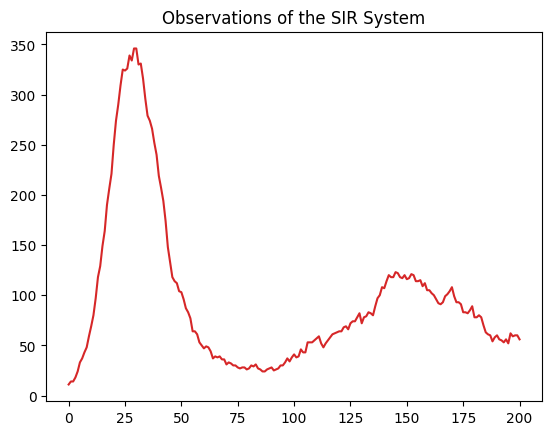

In [3]:
theta = jnp.log(jnp.array([0.3, 0.1, 1 / 90]))
delta_t = 1.0
days = 200
rng_key = jax.random.key(0)
t_range = jnp.arange(0,days + delta_t, delta_t)

SIR_init_key, rng_key = jax.random.split(rng_key)
I_x0 = jax.random.randint(SIR_init_key, minval=0, maxval=20, shape=())

x0 = jnp.full(shape=(3), fill_value=jnp.array([1000, 0, 0]))

x0 = x0.at[0].set(x0[0] - I_x0)
x0 = x0.at[1].set(x0[1] + I_x0)

model_key,rng_key = jax.random.split(rng_key)
full_state = model(
    x0, theta,model_key, t_range
)

observations = full_state[:, 1]

plt.title("Observations of the SIR System")
plt.plot(
        t_range,
        observations.T,
        color="tab:red",
)
plt.show()

In [4]:
def likelihood(particles,observation): 
    return jax.scipy.stats.poisson.logpmf(observation, mu = particles[:,1])

In [5]:
from algorithms.smc import particle_filter 

pf_init_key, rng_key = jax.random.split(rng_key)

num_particles = 100

particles = jnp.full(
    shape=(num_particles, 3), fill_value=jnp.array([1000, 0, 0])
)

particles_I = jax.random.randint(
    pf_init_key, shape=(num_particles), minval=0, maxval=20
)

particles = particles.at[:, 1].set(particles[:, 1] + particles_I)
particles = particles.at[:, 0].set(particles[:, 0] - particles_I)

pf_key,rng_key = jax.random.split(rng_key)
particles,weights = particle_filter(model,observations,particles,pf_key,likelihood,theta,jnp.linspace(0,delta_t,2))

/tmp/ipykernel_1318948/4082389878.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


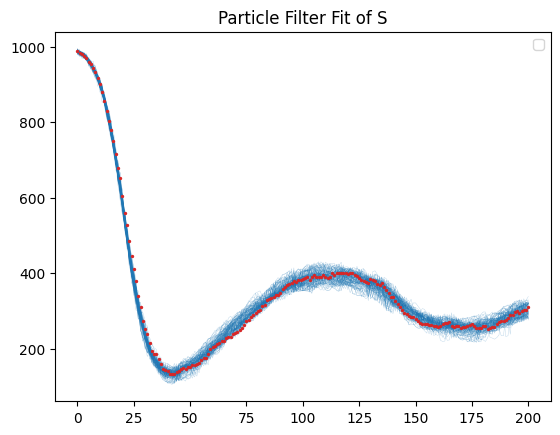

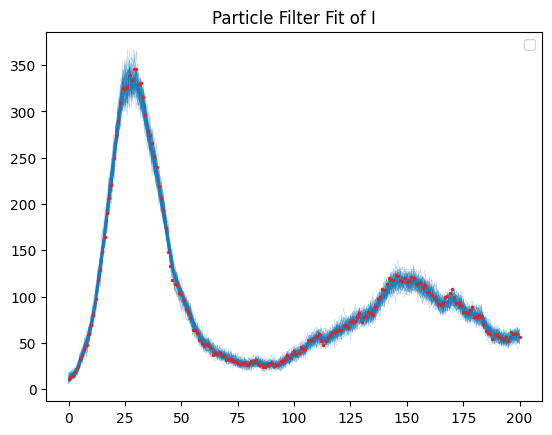

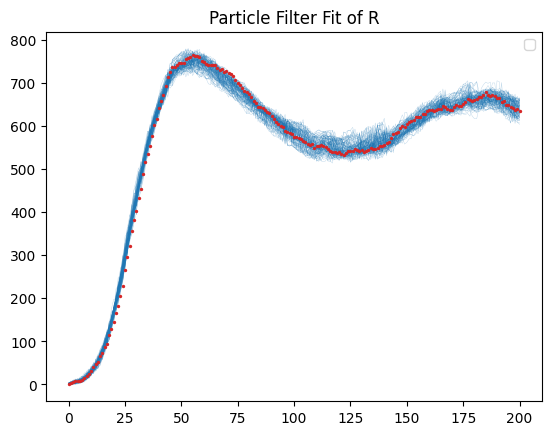

In [6]:
states = ['S','I','R']
for i,state in enumerate(states): 
    plt.title(f"Particle Filter Fit of {state}")
    plt.scatter(
        t_range,
        full_state[:,i].T,
        color="tab:red",
        s = 2.0,
        zorder=100
    )
    plt.plot(
        t_range,
        particles[:,:, i].T,
        lw=0.3,
        alpha = 0.3,
        color="tab:blue",
    )
    plt.legend()
    plt.show()

In [7]:
def data_map(par,key): 
    pf_init_key, key = jax.random.split(key)

    num_particles = 100

    particles = jnp.full(
        shape=(num_particles, 3), fill_value=jnp.array([1000, 0, 0])
    )

    particles_I = jax.random.randint(
        pf_init_key, shape=(num_particles), minval=0, maxval=20
    )

    particles = particles.at[:, 1].set(particles[:, 1] + particles_I)
    particles = particles.at[:, 0].set(particles[:, 0] - particles_I)

    pf_key,key = jax.random.split(key)
    particles,weights = particle_filter(model,observations,particles,pf_key,likelihood,par,jnp.linspace(0,delta_t,2))

    return jnp.mean(particles[:,:,1],axis = 0)

test_runs = 100
test_key,rng_key = jax.random.split(rng_key)
test_keys = jax.random.split(test_key,test_runs)
test_runs = jax.vmap(data_map,in_axes = (None,0))(theta,test_keys)

test_std = jnp.std(test_runs,axis = 0)

print(f"Average deviation: {jnp.mean(test_std)}")

Average deviation: 0.6439114809036255


In [8]:
from algorithms.EKI import EnsembleKalmanInversion

rng_key, noise_key = jax.random.split(rng_key)

dim_output = 3
gamma = 100 * jnp.eye(len(observations))

num_ensemble_members = 25

rng_key, init_ensemble_key, init_key = jax.random.split(rng_key, 3)

initial_ensemble = jnp.log(jnp.array([0.5,0.5,0.1])) + jax.random.normal(
    init_ensemble_key, (num_ensemble_members, dim_output)
)

(final_ensemble,_), _ = EnsembleKalmanInversion(
    initial_ensemble,
    observations,
    gamma,
    lambda x, y: jax.vmap(data_map, in_axes=(0, 0))(x, y),
    0.1,
    init_key,
)

print(jnp.mean(jnp.exp(final_ensemble),axis = 0))

[0.2864461  0.10374694 0.01717208]
